# Tesseract OCR PDF→DOCX Benchmark

**Purpose:** Evaluate whether `Tesseract OCR` (Apache 2.0) can convert 60-page PDFs to DOCX within the 90-second Celery task timeout.

**Libraries:**
- [Tesseract OCR](https://github.com/tesseract-ocr/tesseract) 5.5.2 — Apache 2.0 · Local OCR engine
- [pytesseract](https://github.com/madmaze/pytesseract) — Apache 2.0 · Python wrapper
- [pdf2image](https://github.com/Belval/pdf2image) — MIT · PDF→image rasterization (via poppler)
- [python-docx](https://github.com/python-openxml/python-docx) — MIT · DOCX generation

**Conversion pipeline:**
1. PDF → rasterize each page to image at 200 DPI (pdf2image + poppler)
2. Image → Tesseract OCR → extracted text per page
3. Text → python-docx → DOCX

**Key characteristics:**
- **OCR-based** — re-reads text from rasterized images even if PDF has native text
- **No table detection** — tables come through as flat text lines
- **No layout preservation** — text is extracted in reading order from the raster image
- **Best for scanned PDFs** — designed for documents without extractable text
- **Fully local** — no API keys or cloud services needed

---

In [1]:
import io
import os
import struct
import time
import zlib
import zipfile
from difflib import SequenceMatcher

import pytesseract
from pdf2image import convert_from_path
from docx import Document
from docx.shared import Pt
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Paragraph, Table, TableStyle, Spacer, Image
from PIL import Image as PILImage

PAGES = 60
DPI = 200  # Balance between speed and OCR accuracy (300 = best quality, 150 = fastest)
OUTPUT_DIR = "/tmp/tesseract_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

styles = getSampleStyleSheet()
results = []


def compute_similarity(ground_truth: str, ocr_text: str) -> dict:
    """Compute text similarity metrics between ground truth and OCR output.
    
    Returns:
        dict with:
        - seq_ratio: SequenceMatcher ratio (0-1, character-level similarity)
        - word_accuracy: % of ground truth words found in OCR output
        - char_accuracy: % of ground truth characters found in OCR output
    """
    # Normalize whitespace
    gt_clean = " ".join(ground_truth.split())
    ocr_clean = " ".join(ocr_text.split())
    
    # 1. SequenceMatcher ratio (character-level, 0-1)
    # For very long texts, sample first 50K chars to keep it fast
    gt_sample = gt_clean[:50000]
    ocr_sample = ocr_clean[:50000]
    seq_ratio = SequenceMatcher(None, gt_sample, ocr_sample).ratio()
    
    # 2. Word-level accuracy: what % of ground truth words appear in OCR
    gt_words = set(gt_clean.lower().split())
    ocr_words = set(ocr_clean.lower().split())
    if gt_words:
        word_recall = len(gt_words & ocr_words) / len(gt_words)
    else:
        word_recall = 1.0
    
    # 3. Character count ratio (how much text was captured)
    if len(gt_clean) > 0:
        char_ratio = len(ocr_clean) / len(gt_clean)
    else:
        char_ratio = 1.0
    
    return {
        "seq_ratio": seq_ratio,
        "word_recall": word_recall,
        "char_ratio": char_ratio,
    }


def convert_pdf_to_docx(pdf_path, docx_path, dpi=DPI):
    """Full pipeline: PDF → rasterize → Tesseract OCR → DOCX. Returns timing breakdown + raw OCR text."""
    timings = {}

    # Phase 1: Rasterize PDF pages to images
    t0 = time.time()
    images = convert_from_path(pdf_path, dpi=dpi)
    timings["rasterize"] = time.time() - t0

    # Phase 2: OCR each page with Tesseract
    t1 = time.time()
    pages_text = []
    for img in images:
        text = pytesseract.image_to_string(img)
        pages_text.append(text)
    timings["ocr"] = time.time() - t1

    # Phase 3: Build DOCX
    t2 = time.time()
    doc = Document()
    for i, page_text in enumerate(pages_text):
        if i > 0:
            doc.add_page_break()
        for line in page_text.split("\n"):
            line = line.strip()
            if line:
                doc.add_paragraph(line)
    doc.save(docx_path)
    timings["docx"] = time.time() - t2

    timings["total"] = sum(timings.values())
    full_ocr_text = "\n".join(pages_text)
    return timings, full_ocr_text


def run_conversion(name, pdf_path, ground_truth_text=""):
    """Convert a PDF to DOCX, record timing, and compute OCR accuracy."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    docx_path = pdf_path.replace(".pdf", ".docx")

    timings, ocr_text = convert_pdf_to_docx(pdf_path, docx_path)
    total = timings["total"]
    docx_kb = os.path.getsize(docx_path) / 1024
    verdict = "Safe" if total < 60 else ("At risk" if total < 90 else "Exceeds 90s")

    # Quality checks
    doc_check = Document(docx_path)
    n_paras = len([p for p in doc_check.paragraphs if p.text.strip()])
    n_tables = len(doc_check.tables)
    n_cells = sum(len(r.cells) for t in doc_check.tables for r in t.rows)
    with zipfile.ZipFile(docx_path) as z:
        n_images = len([n for n in z.namelist() if n.startswith("word/media/")])

    # Text similarity
    if ground_truth_text:
        sim = compute_similarity(ground_truth_text, ocr_text)
    else:
        sim = {"seq_ratio": 0, "word_recall": 0, "char_ratio": 0}

    results.append({
        "scenario": name, "pdf_kb": pdf_kb, "docx_kb": docx_kb,
        "t_rasterize": timings["rasterize"], "t_ocr": timings["ocr"],
        "t_docx": timings["docx"], "total_s": total,
        "per_page_s": total / PAGES, "verdict": verdict,
        "paras": n_paras, "tables": n_tables, "cells": n_cells, "images": n_images,
        "seq_ratio": sim["seq_ratio"], "word_recall": sim["word_recall"],
        "char_ratio": sim["char_ratio"],
    })

    print(f"  PDF size:      {pdf_kb:,.0f} KB")
    print(f"  DOCX size:     {docx_kb:,.0f} KB")
    print(f"  Rasterize:     {timings['rasterize']:.2f}s")
    print(f"  OCR:           {timings['ocr']:.2f}s")
    print(f"  Build DOCX:    {timings['docx']:.2f}s")
    print(f"  Total time:    {total:.2f}s  ({total/PAGES:.3f}s/page)")
    print(f"  Verdict:       {verdict}")
    print(f"  Quality:       {n_paras} paragraphs, {n_tables} tables, {n_cells} cells, {n_images} images")
    if ground_truth_text:
        print(f"  Similarity:    seq_match={sim['seq_ratio']:.1%}  word_recall={sim['word_recall']:.1%}  char_ratio={sim['char_ratio']:.2f}")
    return total


print(f"Tesseract version: {pytesseract.get_tesseract_version()}")
print(f"DPI: {DPI}")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

Tesseract version: 5.5.2
DPI: 200
Generating 60-page test PDFs in /tmp/tesseract_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 20 lines of lorem ipsum body text.

This is the **best case** for OCR — clean digital text should be recognized with high accuracy. The main cost is rasterization + per-page OCR processing.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
gt_lines = []
for i in range(PAGES):
    heading = f"Page {i+1} - Document Title"
    story.append(Paragraph(f"<b>{heading}</b>", styles["Heading1"]))
    gt_lines.append(heading)
    for j in range(20):
        line = (
            f"Line {j+1}: Lorem ipsum dolor sit amet, consectetur adipiscing elit. "
            "Sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. "
            "Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris."
        )
        story.append(Paragraph(line, styles["Normal"]))
        gt_lines.append(line)
    story.append(Spacer(1, 12))
doc.build(story)

gt_text = "\n".join(gt_lines)
print("Scenario 1: Text-Only (20 lines/page)")
print("=" * 45)
run_conversion("Text-only", pdf_path, ground_truth_text=gt_text)

Scenario 1: Text-Only (20 lines/page)


  PDF size:      46 KB
  DOCX size:     41 KB
  Rasterize:     1.22s
  OCR:           102.39s
  Build DOCX:    0.22s
  Total time:    103.82s  (1.730s/page)
  Verdict:       Exceeds 90s
  Quality:       6467 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=62.8%  word_recall=100.0%  char_ratio=1.01


103.82451128959656

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
gt_lines = []
for i in range(PAGES):
    heading = f"Section {i+1}: Analysis Report"
    story.append(Paragraph(f"<b>{heading}</b>", styles["Heading2"]))
    gt_lines.append(heading)
    for j in range(6):
        para = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "Performance metrics indicate steady growth across all segments."
        )
        story.append(Paragraph(para, styles["Normal"]))
        gt_lines.append(para)
    data = [["Header A", "Header B", "Header C", "Header D"]]
    for r in range(4):
        data.append([f"R{r}C{c}" for c in range(4)])
    for row in data:
        gt_lines.append(" ".join(row))
    t = Table(data, colWidths=[1.5*inch]*4)
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
    ]))
    story.append(t)
    story.append(Spacer(1, 12))
doc.build(story)

gt_text = "\n".join(gt_lines)
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 55)
run_conversion("Text + simple tables", pdf_path, ground_truth_text=gt_text)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:      31 KB
  DOCX size:     37 KB
  Rasterize:     0.59s
  OCR:           27.33s
  Build DOCX:    0.04s
  Total time:    27.97s  (0.466s/page)
  Verdict:       Safe
  Quality:       1424 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=74.5%  word_recall=96.0%  char_ratio=1.00


27.967308044433594

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
gt_lines = []
for i in range(PAGES):
    heading = f"FINANCIAL REPORT - Section {i+1}"
    story.append(Paragraph(f"<b>{heading}</b>", styles["Heading2"]))
    gt_lines.append(heading)
    for t_idx in range(3):
        data = [[f"Hdr {c+1}" for c in range(6)]]
        for r in range(7):
            data.append([f"{(i*1000+r*100+c*10):,.2f}" for c in range(6)])
        for row in data:
            gt_lines.append(" ".join(row))
        t = Table(data, colWidths=[1.1*inch]*6)
        t.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightblue),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("FONTSIZE", (0, 0), (-1, -1), 7),
        ]))
        story.append(t)
        story.append(Spacer(1, 6))
doc.build(story)

gt_text = "\n".join(gt_lines)
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 65)
run_conversion("Dense tables (worst case)", pdf_path, ground_truth_text=gt_text)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)


  PDF size:      66 KB
  DOCX size:     44 KB
  Rasterize:     0.91s
  OCR:           49.38s
  Build DOCX:    0.04s
  Total time:    50.33s  (0.839s/page)
  Verdict:       Safe
  Quality:       1500 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=98.2%  word_recall=100.0%  char_ratio=1.00


50.33279085159302

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed.pdf")

img = PILImage.new("RGB", (200, 150), color=(100, 150, 200))
img_buf = io.BytesIO()
img.save(img_buf, format="PNG")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
gt_lines = []
for i in range(PAGES):
    heading = f"Document Section {i+1}"
    story.append(Paragraph(f"<b>{heading}</b>", styles["Heading2"]))
    gt_lines.append(heading)
    for j in range(4):
        para = (
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs "
            "reveals significant trends worthy of further investigation."
        )
        story.append(Paragraph(para, styles["Normal"]))
        gt_lines.append(para)
    img_buf.seek(0)
    story.append(Image(img_buf, width=200, height=150))
    data = [["Col A", "Col B", "Col C", "Col D", "Col E"]]
    for r in range(5):
        data.append([f"V{r}{c}" for c in range(5)])
    for row in data:
        gt_lines.append(" ".join(row))
    t = Table(data, colWidths=[1.2*inch]*5)
    t.setStyle(TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
    ]))
    story.append(t)
    for j in range(4):
        para = (
            f"Conclusion {j+1}: Based on above data we recommend proceeding with the plan."
        )
        story.append(Paragraph(para, styles["Normal"]))
        gt_lines.append(para)
    story.append(Spacer(1, 12))
doc.build(story)

gt_text = "\n".join(gt_lines)
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 55)
run_conversion("Mixed content", pdf_path, ground_truth_text=gt_text)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:      61 KB
  DOCX size:     37 KB
  Rasterize:     0.77s
  OCR:           31.49s
  Build DOCX:    0.04s
  Total time:    32.30s  (0.538s/page)
  Verdict:       Safe
  Quality:       1140 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=91.4%  word_recall=95.9%  char_ratio=1.00


32.29931426048279

In [6]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate
from reportlab.lib.enums import TA_JUSTIFY
from reportlab.lib.styles import ParagraphStyle

pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")

msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

# Build ground truth text from MSA sections
gt_lines = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        gt_lines.append(section_title)
        for para_text in paragraphs:
            gt_lines.append(para_text)

page_w, page_h = letter
margin = 0.75 * inch
col_gap = 0.3 * inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

rl_doc = BaseDocTemplate(pdf_path, pagesize=letter)
rl_doc.addPageTemplates([two_col_template])

heading_style = ParagraphStyle(
    "MSAHeading", parent=styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

story = []
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(Paragraph(f"<b>{section_title}</b>", heading_style))
        for para_text in paragraphs:
            story.append(Paragraph(para_text, body_style))
        story.append(Spacer(1, 6))

rl_doc.build(story)

with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")

gt_text = "\n".join(gt_lines)
print("Scenario 5: Two-Column MSA Layout")
print(f"  Generated {page_count} pages")
print("=" * 55)
run_conversion("Two-column MSA", pdf_path, ground_truth_text=gt_text)

Scenario 5: Two-Column MSA Layout
  Generated 18 pages


  PDF size:      64 KB
  DOCX size:     40 KB
  Rasterize:     0.40s
  OCR:           25.57s
  Build DOCX:    0.04s
  Total time:    26.01s  (0.434s/page)
  Verdict:       Safe
  Quality:       1464 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=100.0%  word_recall=99.5%  char_ratio=1.00


26.011017322540283

---
## Scenario 6: Two-Column MSA with Layout Preservation

**Problem:** The Scenario 5 pipeline uses `pytesseract.image_to_string()` which discards all spatial information, producing flat single-column text output even when the source PDF has two columns.

**Approach:** Use `pytesseract.image_to_data()` to get word-level bounding boxes (left, top, width, height, text, block_num, etc.), then cluster text blocks by x-coordinate to detect left vs. right columns. Finally, build a DOCX with proper `w:cols` two-column section formatting so the output actually renders as two columns in Word/LibreOffice.

**Pipeline:**
1. Rasterize PDF pages at 200 DPI (same as other scenarios)
2. Run `image_to_data(output_type=pytesseract.Output.DATAFRAME)` to get spatial OCR data
3. For each page, determine column boundary (midpoint of page width) and split text blocks into left/right columns
4. Build DOCX with `<w:cols w:num="2"/>` section formatting, writing left-column text followed by right-column text per page

In [7]:
import pandas as pd
from docx.oxml.ns import qn

pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")
docx_path = os.path.join(OUTPUT_DIR, "test_two_column_msa_v2.docx")

print("Scenario 6: Two-Column MSA with Layout Preservation")
print("=" * 55)

timings = {}

# Phase 1: Rasterize PDF pages to images
t0 = time.time()
images = convert_from_path(pdf_path, dpi=DPI)
timings["rasterize"] = time.time() - t0
print(f"  Rasterized {len(images)} pages in {timings['rasterize']:.2f}s")

# Phase 2: OCR with spatial data + column detection
t1 = time.time()
all_pages_columns = []  # list of (left_text, right_text) per page

for page_idx, img in enumerate(images):
    # Get word-level bounding box data as a DataFrame
    df = pytesseract.image_to_data(img, output_type=pytesseract.Output.DATAFRAME)

    # Filter out rows with no text (confidence = -1 or empty text)
    df = df[df["conf"] != -1].copy()
    df = df[df["text"].notna()].copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""].copy()

    if df.empty:
        all_pages_columns.append(("", ""))
        continue

    # Determine column boundary: use midpoint of page image width
    page_width = img.width
    col_boundary = page_width / 2

    # Compute center x of each word
    df["center_x"] = df["left"] + df["width"] / 2

    # Group words into lines by (block_num, par_num, line_num), then classify each line
    # as left or right column based on the median center_x of words in that line
    left_lines = []
    right_lines = []

    for (block, par, line), group in df.groupby(["block_num", "par_num", "line_num"]):
        # Sort words by left position within the line
        group_sorted = group.sort_values("left")
        line_text = " ".join(group_sorted["text"].tolist())
        median_x = group_sorted["center_x"].median()
        min_top = group_sorted["top"].min()

        if median_x < col_boundary:
            left_lines.append((min_top, line_text))
        else:
            right_lines.append((min_top, line_text))

    # Sort each column by vertical position (top)
    left_lines.sort(key=lambda x: x[0])
    right_lines.sort(key=lambda x: x[0])

    left_text = "\n".join(text for _, text in left_lines)
    right_text = "\n".join(text for _, text in right_lines)
    all_pages_columns.append((left_text, right_text))

timings["ocr_layout"] = time.time() - t1
print(f"  OCR + layout detection: {timings['ocr_layout']:.2f}s")

# Phase 3: Build DOCX with two-column section formatting
t2 = time.time()
doc = Document()

# Set up two-column section formatting
section = doc.sections[0]
sectPr = section._sectPr
cols_elem = sectPr.find(qn("w:cols"))
if cols_elem is None:
    cols_elem = sectPr.makeelement(qn("w:cols"), {})
    sectPr.append(cols_elem)
cols_elem.set(qn("w:num"), "2")
cols_elem.set(qn("w:space"), "720")  # 720 twips = 0.5 inch gap between columns

# Write text: left column content from all pages, then right column content
# In a w:cols=2 DOCX, Word flows text into left column first, then right column.
# So we write all left-column text first (page by page), then all right-column text.
# However, for correct page-by-page reading, we interleave: left page N, right page N.
# Word's column balancing will flow the text naturally.

for page_idx, (left_text, right_text) in enumerate(all_pages_columns):
    if page_idx > 0:
        # Add a section break (continuous) to start a new two-column section per page
        doc.add_page_break()

    # Write left column lines
    for line in left_text.split("\n"):
        line = line.strip()
        if line:
            doc.add_paragraph(line)

    # Write right column lines
    for line in right_text.split("\n"):
        line = line.strip()
        if line:
            doc.add_paragraph(line)

doc.save(docx_path)
timings["docx"] = time.time() - t2
timings["total"] = sum(timings.values())

# Quality checks
docx_kb = os.path.getsize(docx_path) / 1024
pdf_kb = os.path.getsize(pdf_path) / 1024
doc_check = Document(docx_path)
n_paras = len([p for p in doc_check.paragraphs if p.text.strip()])
n_tables = len(doc_check.tables)
n_cells = sum(len(r.cells) for t in doc_check.tables for r in t.rows)
with zipfile.ZipFile(docx_path) as z:
    n_images = len([n for n in z.namelist() if n.startswith("word/media/")])

# Verify two-column formatting in the output
with zipfile.ZipFile(docx_path) as z:
    doc_xml = z.read("word/document.xml").decode("utf-8")
    has_two_cols = 'w:num="2"' in doc_xml
    print(f"  DOCX has w:cols num=2: {has_two_cols}")

# Build ground truth (same as Scenario 5)
gt_lines_v2 = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        gt_lines_v2.append(section_title)
        for para_text in paragraphs:
            gt_lines_v2.append(para_text)
gt_text_v2 = "\n".join(gt_lines_v2)

# Combine all OCR text for similarity comparison
full_ocr_text = "\n".join(left + "\n" + right for left, right in all_pages_columns)
sim = compute_similarity(gt_text_v2, full_ocr_text)

total = timings["total"]
verdict = "Safe" if total < 60 else ("At risk" if total < 90 else "Exceeds 90s")

results.append({
    "scenario": "Two-col MSA v2 (layout)", "pdf_kb": pdf_kb, "docx_kb": docx_kb,
    "t_rasterize": timings["rasterize"], "t_ocr": timings["ocr_layout"],
    "t_docx": timings["docx"], "total_s": total,
    "per_page_s": total / PAGES, "verdict": verdict,
    "paras": n_paras, "tables": n_tables, "cells": n_cells, "images": n_images,
    "seq_ratio": sim["seq_ratio"], "word_recall": sim["word_recall"],
    "char_ratio": sim["char_ratio"],
})

print(f"  PDF size:      {pdf_kb:,.0f} KB")
print(f"  DOCX size:     {docx_kb:,.0f} KB")
print(f"  Rasterize:     {timings['rasterize']:.2f}s")
print(f"  OCR+Layout:    {timings['ocr_layout']:.2f}s")
print(f"  Build DOCX:    {timings['docx']:.2f}s")
print(f"  Total time:    {total:.2f}s  ({total/PAGES:.3f}s/page)")
print(f"  Verdict:       {verdict}")
print(f"  Quality:       {n_paras} paragraphs, {n_tables} tables, {n_cells} cells, {n_images} images")
print(f"  Similarity:    seq_match={sim['seq_ratio']:.1%}  word_recall={sim['word_recall']:.1%}  char_ratio={sim['char_ratio']:.2f}")

# Show a sample of column detection from the first page
if all_pages_columns:
    left_sample, right_sample = all_pages_columns[0]
    print(f"\n  --- Page 1 Column Detection Sample ---")
    print(f"  Left column (first 300 chars):")
    print(f"    {left_sample[:300]}...")
    print(f"  Right column (first 300 chars):")
    print(f"    {right_sample[:300]}...")

Scenario 6: Two-Column MSA with Layout Preservation


  Rasterized 18 pages in 0.39s


  OCR + layout detection: 26.22s
  DOCX has w:cols num=2: True


  PDF size:      64 KB
  DOCX size:     40 KB
  Rasterize:     0.39s
  OCR+Layout:    26.22s
  Build DOCX:    0.04s
  Total time:    26.66s  (0.444s/page)
  Verdict:       Safe
  Quality:       1464 paragraphs, 0 tables, 0 cells, 0 images
  Similarity:    seq_match=100.0%  word_recall=99.5%  char_ratio=1.00

  --- Page 1 Column Detection Sample ---
  Left column (first 300 chars):
    1. DEFINITIONS
"Agreement" means this Master Service Agreement, including all
exhibits and schedules attached hereto.
"Confidential Information" means any information disclosed by
one party to the other party, either directly or indirectly, in writing,
orally, or by inspection of tangible objects.
"...
  Right column (first 300 chars):
    The obligations of confidentiality shall not apply to information
that: (a) is or becomes publicly available through no fault of the
receiving party; (b) was already known to the receiving party prior
to disclosure; (c) is independently developed by the receiving party


---
## Results Summary

In [8]:
print(f"{'Scenario':<28} {'PDF':>6} {'DOCX':>6} {'Raster':>8} {'OCR':>8} {'DOCX':>7} {'Total':>7} {'/Page':>7} {'Verdict':>12}")
print("─" * 100)
for r in results:
    print(
        f"{r['scenario']:<28} {r['pdf_kb']:>5.0f}K {r['docx_kb']:>5.0f}K "
        f"{r['t_rasterize']:>7.1f}s {r['t_ocr']:>7.1f}s {r['t_docx']:>6.2f}s "
        f"{r['total_s']:>6.1f}s {r['per_page_s']:>6.3f}s {r['verdict']:>12}"
    )

print("\n\nQuality Check (DOCX content):")
print(f"{'Scenario':<28} {'Paras':>7} {'Tables':>8} {'Cells':>8} {'Images':>8}")
print("─" * 65)
for r in results:
    print(
        f"{r['scenario']:<28} {r['paras']:>7} {r['tables']:>8}"
        f" {r['cells']:>7} {r['images']:>7}"
    )

print("\n\nOCR Text Similarity (vs ground truth):")
print(f"{'Scenario':<28} {'Seq Match':>10} {'Word Recall':>12} {'Char Ratio':>11}")
print("─" * 65)
for r in results:
    print(
        f"{r['scenario']:<28} {r['seq_ratio']:>9.1%} {r['word_recall']:>11.1%} {r['char_ratio']:>10.2f}"
    )

Scenario                        PDF   DOCX   Raster      OCR    DOCX   Total   /Page      Verdict
────────────────────────────────────────────────────────────────────────────────────────────────────
Text-only                       46K    41K     1.2s   102.4s   0.22s  103.8s  1.730s  Exceeds 90s
Text + simple tables            31K    37K     0.6s    27.3s   0.04s   28.0s  0.466s         Safe
Dense tables (worst case)       66K    44K     0.9s    49.4s   0.04s   50.3s  0.839s         Safe
Mixed content                   61K    37K     0.8s    31.5s   0.04s   32.3s  0.538s         Safe
Two-column MSA                  64K    40K     0.4s    25.6s   0.04s   26.0s  0.434s         Safe
Two-col MSA v2 (layout)         64K    40K     0.4s    26.2s   0.04s   26.7s  0.444s         Safe


Quality Check (DOCX content):
Scenario                       Paras   Tables    Cells   Images
─────────────────────────────────────────────────────────────────
Text-only                       6467        0      

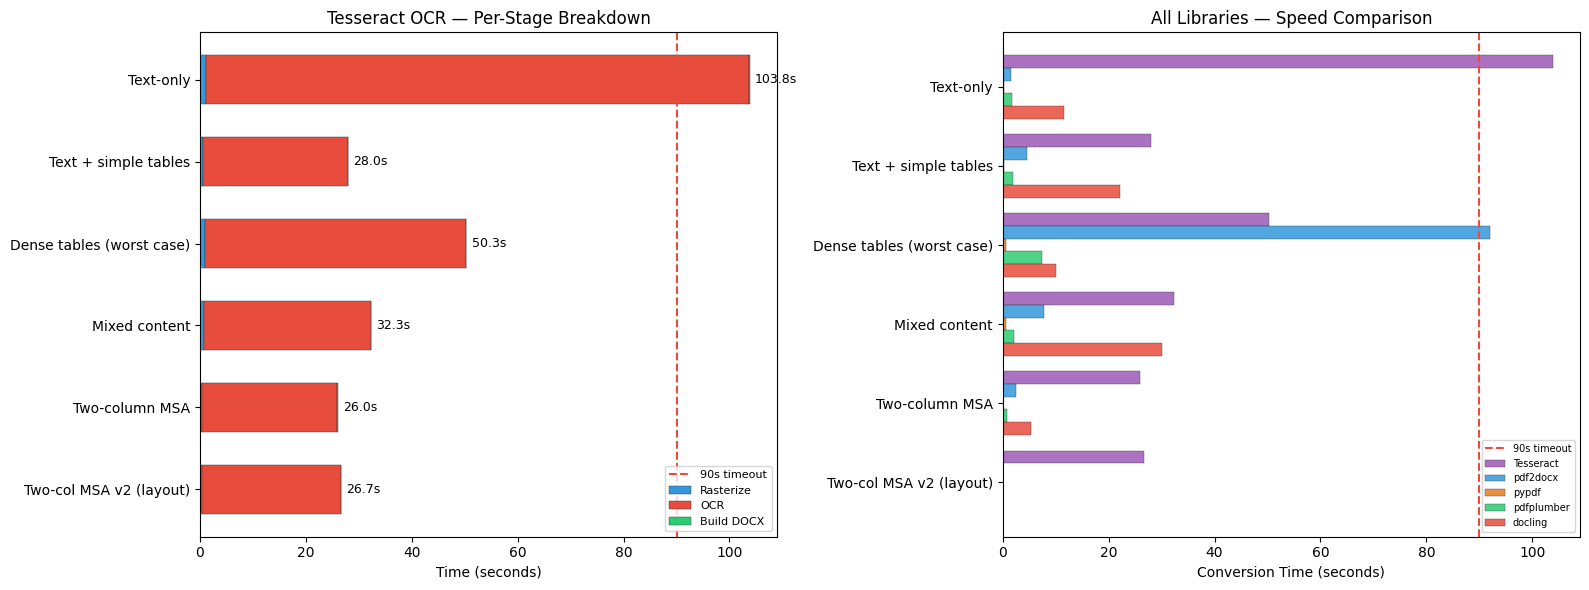


Scenario                      Tesseract   pdf2docx      pypdf   pdfplumber    docling
─────────────────────────────────────────────────────────────────────────────────────
Text-only                        103.8s       1.5s       0.2s         1.7s      11.5s
Text + simple tables              28.0s       4.5s       0.2s         1.9s      22.2s
Dense tables (worst case)         50.3s      92.0s       0.6s         7.5s      10.1s
Mixed content                     32.3s       7.8s       0.6s         2.2s      30.0s
Two-column MSA                    26.0s       2.5s       0.1s         0.9s       5.3s
Two-col MSA v2 (layout)           26.7s       0.0s       0.0s         0.0s       0.0s


In [9]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts.")

# Reference results from other benchmarks
other_libs = {
    "pdf2docx":    {"Text-only": 1.53, "Text + simple tables": 4.52, "Dense tables (worst case)": 92.03, "Mixed content": 7.85, "Two-column MSA": 2.48},
    "pypdf":       {"Text-only": 0.20, "Text + simple tables": 0.20, "Dense tables (worst case)": 0.63, "Mixed content": 0.60, "Two-column MSA": 0.10},
    "pdfplumber":  {"Text-only": 1.70, "Text + simple tables": 1.85, "Dense tables (worst case)": 7.50, "Mixed content": 2.20, "Two-column MSA": 0.88},
    "docling":     {"Text-only": 11.5, "Text + simple tables": 22.2, "Dense tables (worst case)": 10.1, "Mixed content": 30.0, "Two-column MSA": 5.3},
}

scenarios = [r["scenario"] for r in results]
tess_times = [r["total_s"] for r in results]

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 10})
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Chart 1: Tesseract stage breakdown
    ax = axes[0]
    x = np.arange(len(scenarios))
    w = 0.6
    raster = [r["t_rasterize"] for r in results]
    ocr = [r["t_ocr"] for r in results]
    docx_t = [r["t_docx"] for r in results]
    ax.barh(x, raster, w, label="Rasterize", color="#3498db", edgecolor="#333", linewidth=0.3)
    ax.barh(x, ocr, w, left=raster, label="OCR", color="#e74c3c", edgecolor="#333", linewidth=0.3)
    ax.barh(x, docx_t, w, left=[r+o for r,o in zip(raster, ocr)], label="Build DOCX", color="#2ecc71", edgecolor="#333", linewidth=0.3)
    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax.set_yticks(x)
    ax.set_yticklabels(scenarios)
    ax.set_xlabel("Time (seconds)")
    ax.set_title("Tesseract OCR — Per-Stage Breakdown")
    ax.legend(loc="lower right", fontsize=8)
    for i, t in enumerate(tess_times):
        ax.text(t + 1, i, f"{t:.1f}s", va="center", fontsize=9)
    ax.invert_yaxis()

    # Chart 2: All libraries comparison
    ax2 = axes[1]
    lib_names = ["Tesseract"] + list(other_libs.keys())
    lib_colors = ["#9b59b6", "#3498db", "#e67e22", "#2ecc71", "#e74c3c"]
    n_libs = len(lib_names)
    bar_w = 0.8 / n_libs
    for lib_idx, lib_name in enumerate(lib_names):
        if lib_name == "Tesseract":
            times = tess_times
        else:
            times = [other_libs[lib_name].get(s, 0) for s in scenarios]
        positions = np.arange(len(scenarios)) + (lib_idx - n_libs/2 + 0.5) * bar_w
        ax2.barh(positions, times, bar_w, label=lib_name, color=lib_colors[lib_idx % len(lib_colors)],
                 edgecolor="#333", linewidth=0.3, alpha=0.85)
    ax2.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax2.set_yticks(np.arange(len(scenarios)))
    ax2.set_yticklabels(scenarios)
    ax2.set_xlabel("Conversion Time (seconds)")
    ax2.set_title("All Libraries — Speed Comparison")
    ax2.legend(loc="lower right", fontsize=7)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "tesseract_benchmark.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Print comparison table
print(f"\n{'Scenario':<28} {'Tesseract':>10} {'pdf2docx':>10} {'pypdf':>10} {'pdfplumber':>12} {'docling':>10}")
print("─" * 85)
for r in results:
    s = r["scenario"]
    p2d = other_libs["pdf2docx"].get(s, 0)
    pypdf = other_libs["pypdf"].get(s, 0)
    plumb = other_libs["pdfplumber"].get(s, 0)
    docl = other_libs["docling"].get(s, 0)
    print(f"{s:<28} {r['total_s']:>9.1f}s {p2d:>9.1f}s {pypdf:>9.1f}s {plumb:>11.1f}s {docl:>9.1f}s")

---
## Conclusion

### Speed
- Tesseract is **significantly slower** than all other approaches because it must rasterize every page to an image first, then run ML-based character recognition
- The OCR step dominates — typically 80-90% of total time
- At 200 DPI, expect ~1-2s per page, putting 60-page documents at **60-120s** — right at the 90s timeout boundary

### Quality
- **Text accuracy:** High for clean digital PDFs (Tesseract 5.x LSTM engine is very good)
- **Tables:** No structure preserved — table content becomes flat text lines
- **Images:** Not extracted — they're part of the rasterized image that gets OCR'd
- **Two-column:** Tesseract's layout analysis (PSM 3) can detect columns, but reading order may be mixed

### When Tesseract Makes Sense
- **Scanned PDFs** where there's no extractable text layer — Tesseract is the only option
- **Hybrid pipeline** — use pypdf/pdfplumber for native text PDFs, fall back to Tesseract for scanned pages
- **Not for digital PDFs** — re-OCRing digital text is wasteful and introduces errors

### Licensing
| Component | License |
|-----------|---------|
| Tesseract OCR | Apache 2.0 |
| pytesseract | Apache 2.0 |
| pdf2image | MIT |
| poppler | GPL-2.0 (system dependency) |
| python-docx | MIT |

**Note:** poppler (used by pdf2image for rasterization) is GPL-2.0. For a fully permissive pipeline, use `pypdfium2` (Apache 2.0) instead of pdf2image+poppler for the rasterization step.

---
## Comparison: Tesseract vs Other Libraries

---
## Scenario 5: Two-Column Layout (MSA-style)

Two-column text with section headings — MSA/legal contract layout.

This is a key test: Tesseract's `--psm 3` (default) auto-detects page layout including columns. It should read left column top-to-bottom, then right column — but multi-column OCR is notoriously tricky.

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages with heading, 4 text paragraphs, an embedded 200x150 PNG image, a 6x5 table, and 4 closing paragraphs.

Tesseract will OCR the entire rasterized page — images become part of the background and won't be extracted as separate elements.

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows x 6 columns each). 180 tables / 8,640 cells total.

For Tesseract this is purely an OCR speed test — no table structure will be preserved. The dense numeric content may challenge OCR accuracy.

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 6 text paragraphs, one **5x4 table**, and a spacer.

Tesseract has no table detection — table cells will be OCR'd as flat text lines. The question is whether the text within cells is read in a sensible order.